<a href="https://colab.research.google.com/github/Oliwash254/machine-learning/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
%matplotlib inline
#reading Data
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [2]:
titanic_data= pd.read_csv('titanic.csv')

In [3]:
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
print("# of passengers in original data:" +str(len(titanic_data.index)))

# of passengers in original data:891


##analyzing Data##


<Axes: xlabel='Survived', ylabel='count'>

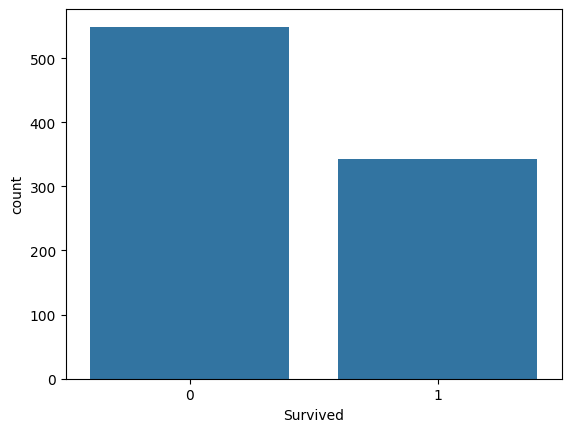

In [5]:
#analyzing Data
sns.countplot(x='Survived',data=titanic_data)


<Axes: xlabel='Survived', ylabel='count'>

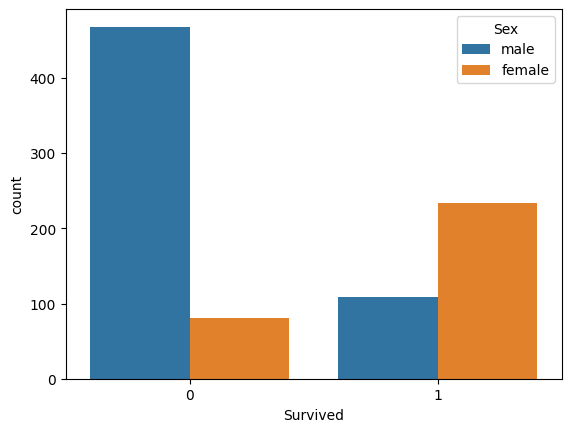

In [6]:
sns.countplot(x='Survived',hue='Sex',data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

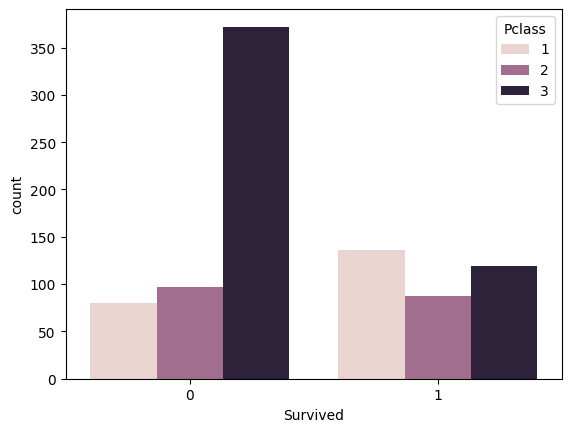

In [7]:
sns.countplot(x='Survived',hue='Pclass',data=titanic_data)

<Axes: ylabel='Frequency'>

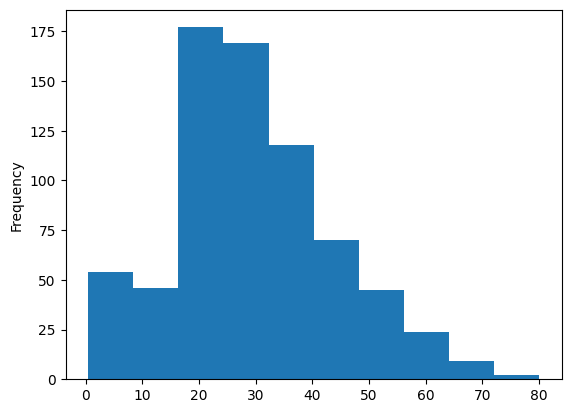

In [8]:
titanic_data['Age'].plot.hist()


<Axes: ylabel='Frequency'>

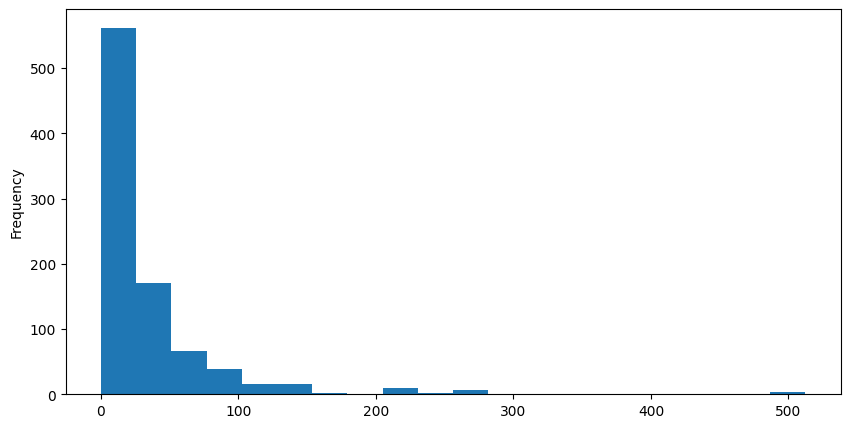

In [9]:
titanic_data['Fare'].plot.hist(bins=20,figsize=(10,5))

In [10]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: xlabel='SibSp', ylabel='count'>

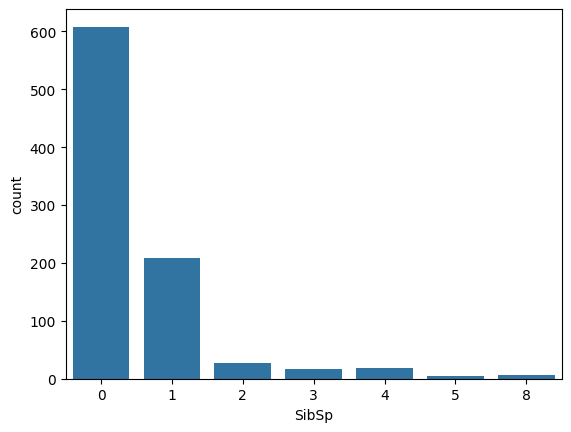

In [11]:
sns.countplot(x='SibSp',data=titanic_data)

##data wrangling/ data cleaning##


In [13]:
titanic_data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

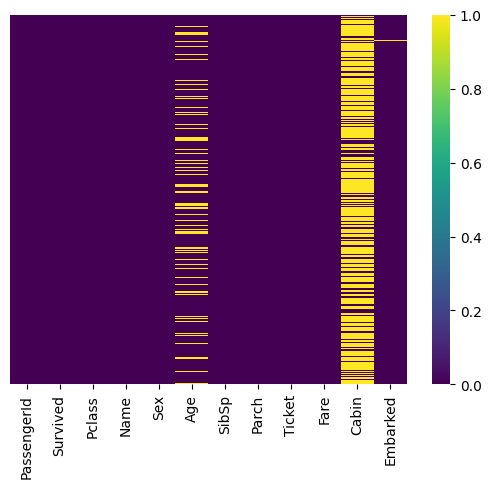

In [15]:
sns.heatmap(titanic_data.isnull(),yticklabels=False,cbar=True,cmap='viridis')

<Axes: xlabel='Pclass', ylabel='Age'>

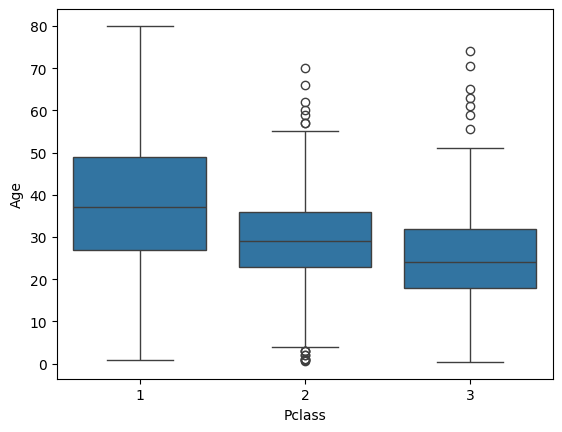

In [16]:
sns.boxplot(x='Pclass',y='Age',data=titanic_data)

In [17]:
titanic_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
titanic_data.drop('Cabin',axis=1,inplace=True)

In [19]:
titanic_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [20]:
titanic_data.dropna(inplace=True)

<Axes: >

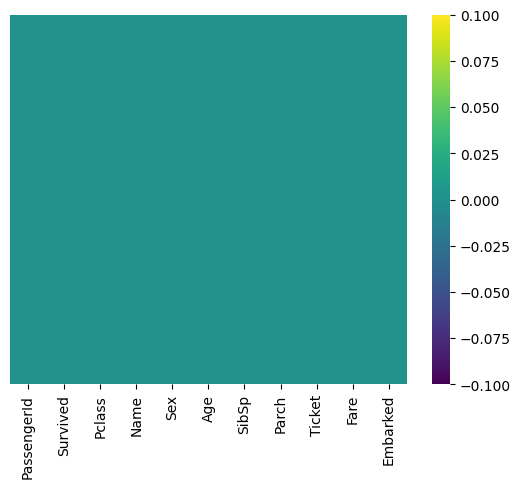

In [21]:
sns.heatmap(titanic_data.isnull(),yticklabels=False,cbar=True,cmap='viridis')

In [22]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [23]:
titanic_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [24]:
sex = pd.get_dummies(titanic_data['Sex'], drop_first=True).astype(int)
sex.head(5)

,male
0,1
1,0
2,0
3,0
4,1


In [25]:
embark = pd.get_dummies(titanic_data['Embarked'], drop_first=True).astype(int)
embark.head(5)

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [27]:
if 'Pclass' in titanic_data.columns:
    titanic_data.drop(['Pclass'], axis=1, inplace=True)


In [28]:
print(titanic_data.columns.tolist())


['PassengerId', 'Survived', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [ ]:
titanic_data= pd.read_csv('titanic.csv')

In [30]:
print(titanic_data.columns[titanic_data.columns.duplicated()])


Index([], dtype='object')


In [31]:
print(titanic_data.columns.tolist())


['PassengerId', 'Survived', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [33]:
# Drop unneeded columns
titanic_data.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# One-hot encode 'Sex' and 'Embarked'
sex = pd.get_dummies(titanic_data['Sex'], drop_first=True)
embark = pd.get_dummies(titanic_data['Embarked'], drop_first=True)

# Merge encoded columns and drop originals
titanic_data = pd.concat([titanic_data, sex, embark], axis=1)
titanic_data.drop(['Sex', 'Embarked'], axis=1, inplace=True)


In [34]:
print(titanic_data.isnull().sum())


Survived    0
Age         0
SibSp       0
Parch       0
Fare        0
male        0
Q           0
S           0
dtype: int64


In [51]:
# Fill missing Age values with median
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median())


# Define features (X) and target (y)
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']


In [36]:
titanic_data.head(5)

,Survived,Age,SibSp,Parch,Fare,male,Q,S
0,0,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,1,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,0,35.0,0,0,8.0500,True,False,True


In [37]:
#titanic_data.drop(['Pclass'],axis=1,inplace=True)

In [38]:
titanic_data.head(5)

,Survived,Age,SibSp,Parch,Fare,male,Q,S
0,0,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,1,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,0,35.0,0,0,8.0500,True,False,True


In [39]:
!pip install xgboost


##training and testing the model##


In [48]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Optional: XGBoost (install if not available)
try:
    from xgboost import XGBClassifier
    use_xgboost = True
except ImportError:
    use_xgboost = False

# 1. Fill missing values
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)

# 2. Define X and y
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

if use_xgboost:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# 6. Train and evaluate
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

# 7. Display results
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
print(results_df)


/tmp/ipython-input-48-1523979491.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)


                 Model  Accuracy
2                  SVM  0.818182
5    Gradient Boosting  0.797203
4          Naive Bayes  0.783217
0  Logistic Regression  0.776224
1        Random Forest  0.755245
3                  KNN  0.755245
6              XGBoost  0.755245


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [12:45:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/tmp/ipython-input-52-2190276125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


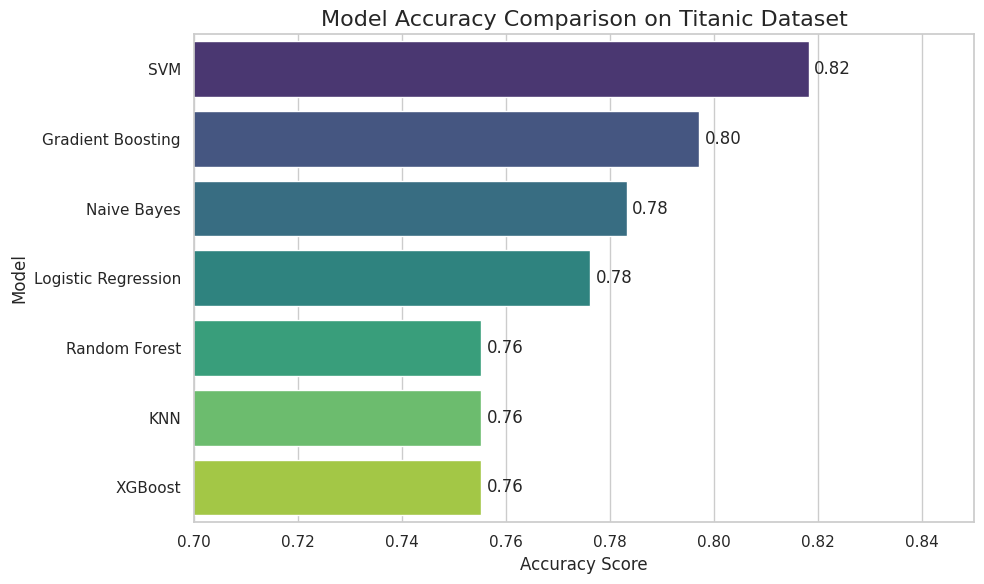

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style
sns.set(style="whitegrid")

# Sort results by accuracy if not already sorted
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")

plt.title("Model Accuracy Comparison on Titanic Dataset", fontsize=16)
plt.xlabel("Accuracy Score", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.xlim(0.7, 0.85)  # adjust limits if needed

# Show value labels on bars
for index, value in enumerate(results_df["Accuracy"]):
    plt.text(value + 0.001, index, f"{value:.2f}", va='center')

plt.tight_layout()
plt.show()


##Train the svm model##


In [61]:
from sklearn.svm import SVC

# Re-initialize and train the SVM model
best_model = SVC(probability=True)  # use `probability=True` if you want probability outputs
best_model.fit(X_train_scaled, y_train)


SVC(probability=True)

##make predition##

In [62]:
# Predict on the test set
y_pred = best_model.predict(X_test_scaled)

# (Optional) Predict probabilities
y_proba = best_model.predict_proba(X_test_scaled)  # Useful for ROC or thresholds


Accuracy: 0.8181818181818182

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84        80
           1       0.82      0.75      0.78        63

    accuracy                           0.82       143
   macro avg       0.82      0.81      0.81       143
weighted avg       0.82      0.82      0.82       143



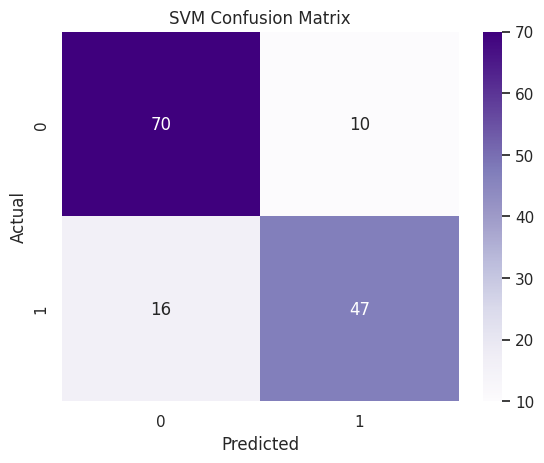

In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [66]:
#save model using joblib
import joblib
joblib.dump(best_model, 'titanic_svm_model.pkl')

['titanic_svm_model.pkl']